In [1]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from stepmix.stepmix import StepMix
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity


import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv('C:\\Users\\xavis\\Xavier\\Benestar-e\\DATA\\DADES_EXCEL_TOTS_v05.csv', sep=';')
print(df.shape)
df.head()

(846, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [3]:
## Check the distribution of the 'Tranquil·litzants/pastilles per dormir' variable
df['Tranquil·litzants/pastilles per dormir'].value_counts() ## 1==yes, 2==no

Tranquil·litzants/pastilles per dormir
2.0    592
1.0    156
Name: count, dtype: int64

In [4]:
## Check the distribution of the 'Descans' variable
df['descans'].value_counts(), ## 1==yes, 2==no

(descans
 1.0    376
 2.0    372
 Name: count, dtype: int64,)

In [5]:
## Change the 'Tranquil·litzants/pastilles per dormir' variable to binary (1 for yes, 0 for no)
df['Tranquil·litzants/pastilles per dormir'] = df['Tranquil·litzants/pastilles per dormir'].replace(2, 0)  ## 1==yes, 0==no

print(df.shape)
print(df['Tranquil·litzants/pastilles per dormir'].value_counts())
df.head()

(846, 261)
Tranquil·litzants/pastilles per dormir
0.0    592
1.0    156
Name: count, dtype: int64


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [6]:
## Change the 'Descans' variable to binary (1 for yes, 0 for no) 
df['descans'] = df['descans'].replace(2, 0) ## 1==yes, 0==no

print(df.shape)
print(df['descans'].value_counts())
df.head()

(846, 261)
descans
1.0    376
0.0    372
Name: count, dtype: int64


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [7]:
## Check the distribution of the 'GRUP' variable
students = df[df['GRUP'] == 1]
print(students.shape)
students.head()

(450, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [8]:
# Check the unique values of the 'genere' (gender) variable in students
students['genere'].unique()

array([1, 2, 4, 3], dtype=int64)

In [9]:
# Using dropna() for Cluster_Estudiants
students = students.dropna(subset=['Cluster_Estudiants'])
print(f"Final shape: {students.shape}")
print("Cluster distribution:")
print(students['Cluster_Estudiants'].value_counts())

print(students.shape)
students.head()

Final shape: (368, 261)
Cluster distribution:
Cluster_Estudiants
0.0    236
1.0    132
Name: count, dtype: int64
(368, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [10]:
## verify if there are any missing values in students
students.isna().sum().sum()

15719

In [11]:
## check again the gender unique values after deleting NaN values in Cluster_Estudiants
students['genere'].unique()

array([1, 2], dtype=int64)

In [12]:
# cheking the distribution of the 'genere' variable in students
students['genere'].value_counts(), ## 1==male, 2==female

(genere
 2    256
 1    112
 Name: count, dtype: int64,)

In [13]:
# Change the 'genere' variable to 1=woman and 0=man
students['genere'] = students['genere'].replace({1: 0, 2: 1}) ## 1==woman, 0==man

print(df.shape)
print(students['genere'].value_counts())
students.head()

(846, 261)
genere
1    256
0    112
Name: count, dtype: int64


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,0,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [14]:
## rename the 'FACTOR1_BENESTAR_N100' column to 'Well-being Emotional Factor Five'
students.rename(columns={'FACTOR1_BENESTAR_N100': 'Well-being Emotional Factor Five'}, inplace=True)

In [15]:
# Selecting the relevant columns for the analysis
sociodemo = ['ID',
 'genere',
 'edat_categorica_REDUIDA',
 'nacionalitat_DICO',
 'salud',
 'situacio_economica',
 'esport',
 'hores_fisic',
 'risc_alcohol',
 'Tranquil·litzants/pastilles per dormir',
 'consum-DROGUES',
 'fumador',
 'n_cigarretes_dia',
 'son',
 'descans',
 'estudis_uvic_RECODIFICATS',
 'curs_uvic_RECODIFICATS',
 'Well-being Emotional Factor Five',
 'Cluster_Estudiants']

In [16]:
## Create a new dataframe with only the selected columns
students = students[sociodemo]
print(students.shape)
students.head()

(368, 19)


,ID,genere,edat_categorica_REDUIDA,nacionalitat_DICO,salud,situacio_economica,esport,hores_fisic,risc_alcohol,Tranquil·litzants/pastilles per dormir,consum-DROGUES,fumador,n_cigarretes_dia,son,descans,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,Well-being Emotional Factor Five,Cluster_Estudiants
0,1,0,1.0,1,4,2,1.0,2.0,0.0,0.0,1.0,3.0,1.0,1.0,1.0,1.0,2.0,85.531279,1.0
1,2,1,2.0,2,4,3,2.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,54.925788,0.0
2,3,1,1.0,1,4,1,1.0,3.0,0.0,0.0,1.0,3.0,1.0,2.0,0.0,1.0,4.0,52.101994,0.0
13,14,0,1.0,1,5,3,1.0,4.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0,1.0,2.0,46.040875,0.0
14,15,0,1.0,1,5,3,1.0,4.0,0.0,0.0,1.0,1.0,0.0,2.0,1.0,1.0,2.0,66.156995,1.0


In [17]:
## Delete & verify missing values in estudiants
students = students.dropna()
print(f"New shape: ", students.shape)
print(students.isna().sum())


New shape:  (365, 19)
ID                                        0
genere                                    0
edat_categorica_REDUIDA                   0
nacionalitat_DICO                         0
salud                                     0
situacio_economica                        0
esport                                    0
hores_fisic                               0
risc_alcohol                              0
Tranquil·litzants/pastilles per dormir    0
consum-DROGUES                            0
fumador                                   0
n_cigarretes_dia                          0
son                                       0
descans                                   0
estudis_uvic_RECODIFICATS                 0
curs_uvic_RECODIFICATS                    0
Well-being Emotional Factor Five          0
Cluster_Estudiants                        0
dtype: int64


In [18]:
# Verifing the distribution of the 'Cluster_students' variable after dropping NaN values in sociodemographic variables
students['Cluster_Estudiants'].value_counts()

Cluster_Estudiants
0.0    234
1.0    131
Name: count, dtype: int64

In [19]:
## verifing the number of unique categories in each column of students
for col in students.columns:
    print(f"{col}: {students[col].nunique()} categories")

ID: 365 categories
genere: 2 categories
edat_categorica_REDUIDA: 3 categories
nacionalitat_DICO: 2 categories
salud: 5 categories
situacio_economica: 4 categories
esport: 2 categories
hores_fisic: 6 categories
risc_alcohol: 2 categories
Tranquil·litzants/pastilles per dormir: 2 categories
consum-DROGUES: 2 categories
fumador: 3 categories
n_cigarretes_dia: 4 categories
son: 2 categories
descans: 2 categories
estudis_uvic_RECODIFICATS: 5 categories
curs_uvic_RECODIFICATS: 7 categories
Well-being Emotional Factor Five: 358 categories
Cluster_Estudiants: 2 categories


In [20]:
## Normality tests for 'Well-being Emotional Factor Five'

from scipy.stats import shapiro, normaltest, kstest
import pandas as pd

print("Normality tests for Well-being Emotional Factor Five:")
x = students["Well-being Emotional Factor Five"].dropna()

# Shapiro-Wilk
stat, p = shapiro(x)
print(f"Shapiro-Wilk → statistic={stat:.3f}, p={p:.3f}")

# D’Agostino & Pearson
stat2, p2 = normaltest(x)
print(f"D’Agostino-Pearson → statistic={stat2:.3f}, p={p2:.3f}")

# Kolmogorov-Smirnov
from scipy.stats import norm
stat3, p3 = kstest(x, 'norm', args=(x.mean(), x.std()))
print(f"Kolmogorov-Smirnov → statistic={stat3:.3f}, p={p3:.3f}")


Normality tests for Well-being Emotional Factor Five:
Shapiro-Wilk → statistic=0.995, p=0.369
D’Agostino-Pearson → statistic=2.170, p=0.338
Kolmogorov-Smirnov → statistic=0.033, p=0.797


UPDATED CODES:
genere                                   → B (Dicotomic authentic)
edat_categorica_REDUIDA                  → D (Ordinal/rangs)
nacionalitat_DICO                        → B (Dicotomic authentic)
salud                                    → D (Ordinal/rangs)
situacio_economica                       → D (Ordinal/rangs)
esport                                   → B (Dicotomic authentic)
hores_fisic                              → D (Ordinal/rangs)
risc_alcohol                             → C (Dicotomic artificial)
Tranquil·litzants/pastilles per dormir   → B (Dicotomic authentic)
consum-DROGUES                           → B (Dicotomic authentic)
fumador                                  → A (Nominal 3+ cat)
n_cigarretes_dia                         → D (Ordinal/rangs)
son                                      → B (Dicotomic authentic)
descans                                  → B (Dicotomic authentic)
estudis_uvic_RECODIFICATS                → A (Nominal 3+ cat)
curs_uvic_RECODIFIC

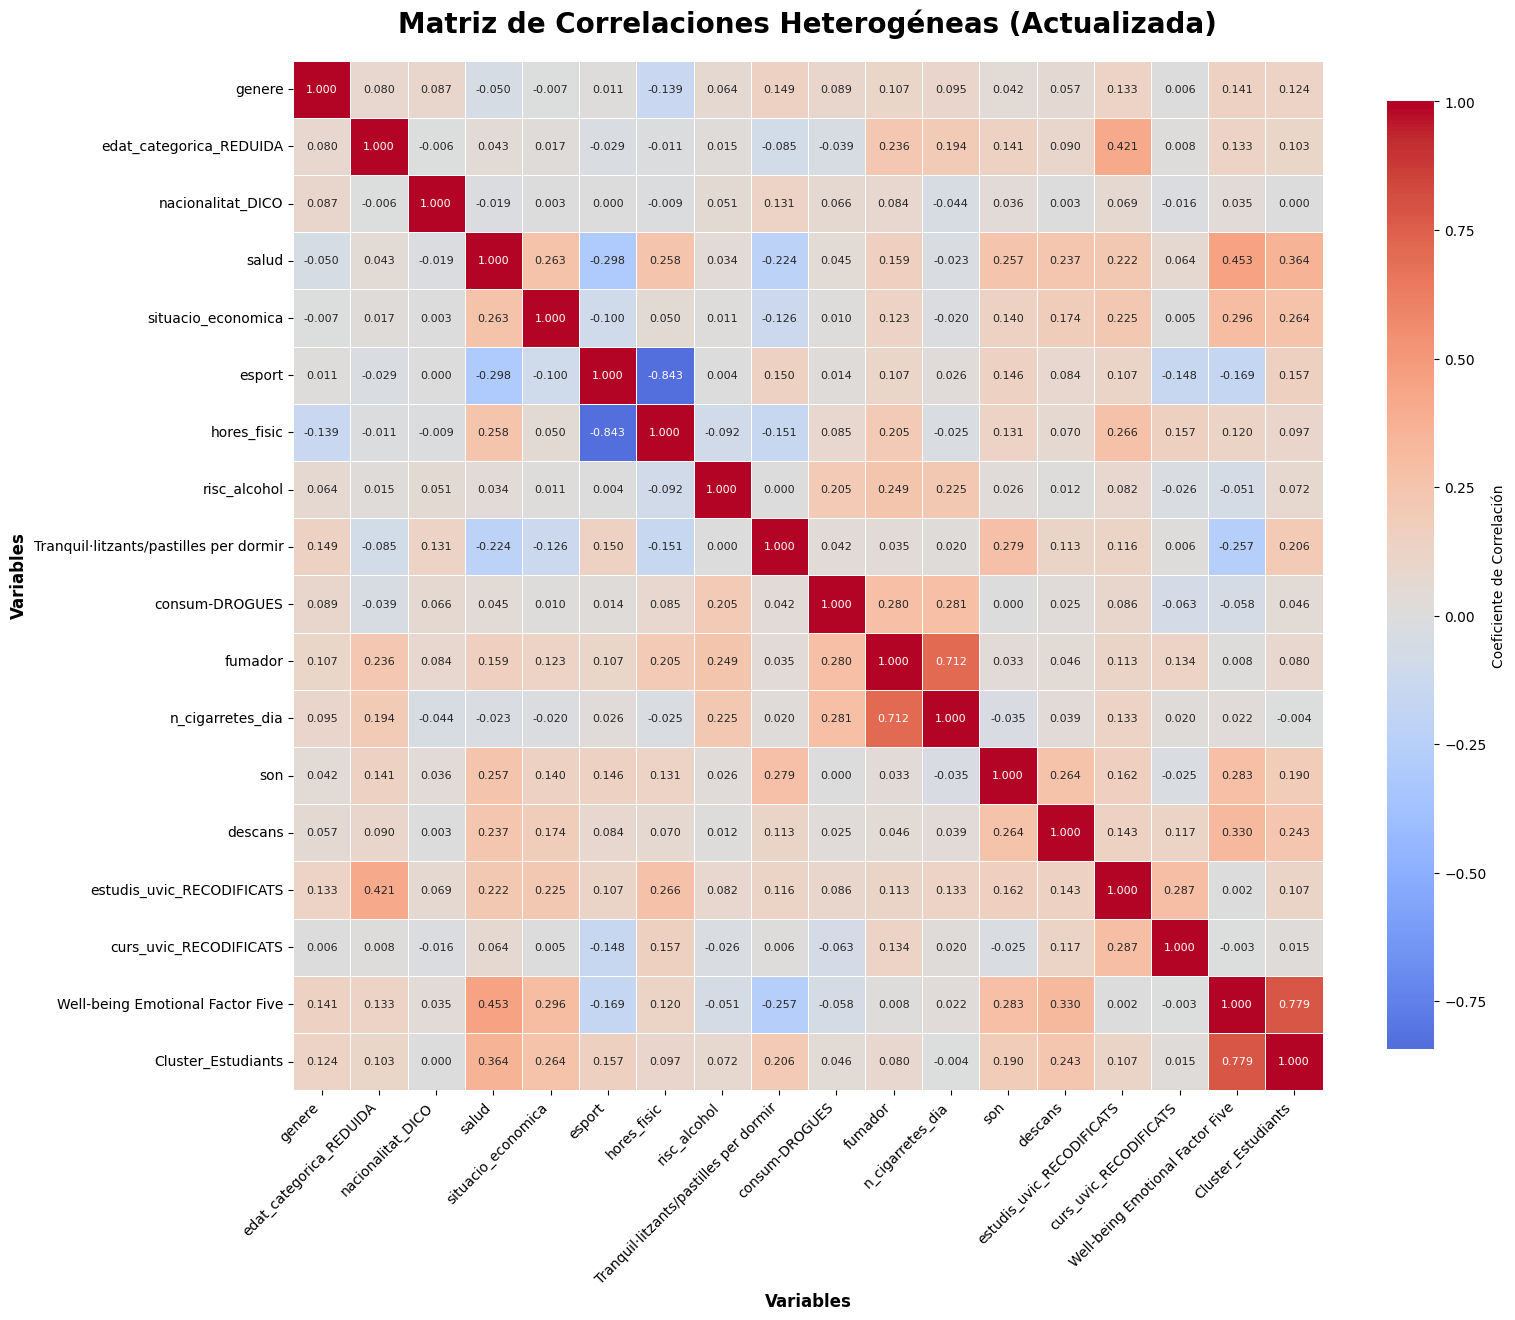


UPDATED CORRELATION MATRIX:
                                        genere  edat_categorica_REDUIDA  \
genere                                   1.000                    0.080   
edat_categorica_REDUIDA                  0.080                    1.000   
nacionalitat_DICO                        0.087                   -0.006   
salud                                   -0.050                    0.043   
situacio_economica                      -0.007                    0.017   
esport                                   0.011                   -0.029   
hores_fisic                             -0.139                   -0.011   
risc_alcohol                             0.064                    0.015   
Tranquil·litzants/pastilles per dormir   0.149                   -0.085   
consum-DROGUES                           0.089                   -0.039   
fumador                                  0.107                    0.236   
n_cigarretes_dia                         0.095                    0.194

In [21]:
## Applying the correlation matrix function to the estudiants dataframe with the updated variable types

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, pointbiserialr, chi2_contingency
from scipy.stats.contingency import association
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scipy.stats import kendalltau

# --- Función Phi de Pearson (for dichotomous variables)
def phi_pearson(x, y):
    """Phi coefficient for two authentic dichotomous variables"""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    return np.sqrt(chi2 / n)

# --- Función Tetracórica (approximation for dichotomous variables)
def tetrachorica_aprox(x, y):
    """Approximation of tetrachoric correlation using transformation"""
    try:
        # Convert to 0/1 if not already
        x_bin = (x == x.max()).astype(int)
        y_bin = (y == y.max()).astype(int)
        # Use phi as approximation
        return phi_pearson(x_bin, y_bin)
    except:
        return np.nan

# --- Función Biserial (approximation)
def biserial_aprox(cont, dico):
    """Approximation of biserial correlation"""
    try:
        # Use point-biserial as improved approximation
        return pointbiserialr(dico, cont)[0]
    except:
        return np.nan

# --- Contingency Coefficient Function
def coeficiente_contingencia(x, y):
    """Contingency coefficient for nominal variables"""
    try:
        tabla = pd.crosstab(x, y)
        chi2 = chi2_contingency(tabla)[0]
        n = tabla.sum().sum()
        return np.sqrt(chi2 / (chi2 + n))
    except:
        return np.nan

def kruskal_wallis_effect_size(nominal, continua):
    
    """Calculates Kruskal-Wallis test and its effect size (epsilon-squared)
    for nominal vs continuous when normality is not present"""
    try:
        # Create groups based on the nominal variable
        groups = [continua[nominal == category].dropna() for category in nominal.unique()]
        
        # Filter out empty groups
        groups = [group for group in groups if len(group) > 0]
        
        if len(groups) < 2:
            return np.nan
        
        # Kruskal-Wallis test
        h_stat, p_value = kruskal(*groups)
        
        # Calculate epsilon-squared (effect size for Kruskal-Wallis)
        n_total = sum(len(group) for group in groups)
        epsilon_squared = (h_stat - len(groups) + 1) / (n_total - len(groups))
        
        # Ensure it is between 0 and 1
        epsilon_squared = max(0, min(1, epsilon_squared))
        
        return epsilon_squared
        
    except Exception as e:
        return np.nan

# --- Main function UPDATED according to your table
def matriz_correlacion_mixta(df, codigos):
    
    """
    Heterogeneous correlation matrix based on variable types
    codigos = {'var1':'A','var2':'B',...}
    A = Nominal 3+ categories
    B = Authentic dichotomous  
    C = Artificial dichotomous
    D = Ordinal/ranks
    E = Continuous normal
    F = Continuous NON-normal
    """

    vars_all = [v for v in df.columns if v in codigos]
    n = len(vars_all)
    
    corr_matrix = pd.DataFrame(np.zeros((n,n)), index=vars_all, columns=vars_all)
    metodo_matrix = pd.DataFrame('', index=vars_all, columns=vars_all)

    for i, var1 in enumerate(vars_all):
        for j, var2 in enumerate(vars_all):

            if i == j:
                corr_matrix.loc[var1, var2] = 1.0
                metodo_matrix.loc[var1, var2] = "Diagonal"
                continue

            x, y = df[var1], df[var2]
            t1, t2 = codigos[var1], codigos[var2]

            try:
                # --- COMBINED KEYS (order alphabetically) ---
                combo = ''.join(sorted([t1, t2]))

                if combo == "CC":  # Dicotomic artificial ↔ Dicotomic artificial
                    r = tetrachorica_aprox(x, y)
                    metodo = "Tetracórica"

                elif combo == "CE":  # Dicotomic artificial ↔ Continuous normal
                    r = biserial_aprox(y if t2 == 'E' else x, x if t2 == 'E' else y)
                    metodo = "Biseriada"

                elif combo == "BB":  # Dicotomic authentic ↔ Dicotomic authentic
                    r = phi_pearson(x, y)
                    metodo = "Phi de Pearson"

                elif combo == "BE":  # Dicotomic authentic ↔ Continuous normal
                    r = pointbiserialr(x if t1 == 'B' else y, y if t1 == 'B' else x)[0]
                    metodo = "Point-biserial"

                elif combo == "EE":  # Continuous normal ↔ Continuous normal
                    r, _ = pearsonr(x, y)
                    metodo = "Pearson"

                elif combo == "EF":  # Continuous normal ↔ Continuous NON-normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "FF":  # Continuous NON-normal ↔ Continuous NON-normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "DD":  # Ordinal ↔ Ordinal
                    r, _ = kendalltau(x, y)
                    metodo = "Kendall-Tau"

                elif combo == "BD":  # Dicotomic authentic ↔ Ordinal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "CD":  # Dicotomic artificial ↔ Ordinal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "AD":  # Nominal ↔ Ordinal
                    r = coeficiente_contingencia(x, y)
                    metodo = "Coeficiente de contingencia"

                elif combo == "AA":  # Nominal ↔ Nominal
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Cramer's V"

                elif combo == "AF":  # Nominal ↔ Continuous NON-normal
                    r = kruskal_wallis_effect_size(x if t1 == 'A' else y, y if t1 == 'A' else x)
                    metodo = "Kruskal-Wallis"

                elif combo == "AE":  # Nominal ↔ Continuous normal
                    r = kruskal_wallis_effect_size(x if t1 == 'A' else y, y if t1 == 'A' else x)
                    metodo = "Kruskal-Wallis"

                elif combo == "BC":  # Dicotomic authentic ↔ Dicotomic artificial
                    r = phi_pearson(x, y)
                    metodo = "Phi de Pearson"

                elif combo == "AB":  # Nominal ↔ Dicotomic authentic
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Chi-cuadrado/Cramer's V"

                elif combo == "AC":  # Nominal ↔ Dicotomic artificial
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Cramer's V"

                elif combo == "BF":  # Dicotomic authentic ↔ Continuous NON-normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "CF":  # Dicotomic artificial ↔ Continuous NON-normal
                    r = biserial_aprox(y if t2 == 'F' else x, x if t2 == 'F' else y)
                    metodo = "Biseriada/Mann-Whitney"

                elif combo == "DE":  # Ordinal ↔ Continuous normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "DF":  # Ordinal ↔ Continuous NON-normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                else:
                    r = np.nan
                    metodo = "No definido"

            except:
                r = np.nan
                metodo = "Error"

            corr_matrix.loc[var1, var2] = r
            metodo_matrix.loc[var1, var2] = metodo

    # VISUALIZATION
    plt.figure(figsize=(16, 14))
    
    sns.heatmap(
        corr_matrix.astype(float), 
        cmap='coolwarm', 
        center=0,
        annot=True, 
        fmt='.3f',
        annot_kws={'size': 8},
        square=True, 
        linewidths=0.5,
        cbar_kws={"shrink": .8, "label": "Coeficiente de Correlación"}
    )
    
    plt.title("Matriz de Correlaciones Heterogéneas (Actualizada)", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Variables", fontsize=12, fontweight='bold')
    plt.ylabel("Variables", fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

    return corr_matrix, metodo_matrix

codigos_actualizados = {
    "genere": "B",                           # Dicotomic authentic
    "edat_categorica_REDUIDA": "D",          # Ordinal 3 cat
    "nacionalitat_DICO": "B",                # Dicotomic authentic
    "salud": "D",                           # Ordinal 5 cat
    "situacio_economica": "D",              # Ordinal 4 cat
    "esport": "B",                          # Dicotomic authentic
    "hores_fisic": "D",                     # Ordinal 6 cat
    "risc_alcohol": "C",                    # Dicotomic artificial
    "Tranquil·litzants/pastilles per dormir": "B",  # Dicotomic authentic
    "consum-DROGUES": "B",                  # Dicotomic authentic
    "fumador": "A",                         # Nominal 3 cat
    "n_cigarretes_dia": "D",               # Ordinal 4 cat
    "son": "B",                            # Dicotomic authentic
    "descans": "B",                        # Dicotomic authentic
    "estudis_uvic_RECODIFICATS": "A",      # Nominal 5 cat
    "curs_uvic_RECODIFICATS": "D",         # Ordinal 7 cat
    "Well-being Emotional Factor Five": "F",               # Continuous NON-normal
    "Cluster_Estudiants": "C"     # Dicotomic artificial
}

print("UPDATED CODES:")
for var, codigo in codigos_actualizados.items():
    tipo_desc = {
        'A': 'Nominal 3+ cat',
        'B': 'Dicotomic authentic', 
        'C': 'Dicotomic artificial',
        'D': 'Ordinal/rangs',
        'E': 'Continuous normal',
        'F': 'Continuous NON-normal'
    }
    print(f"{var:<40} → {codigo} ({tipo_desc[codigo]})")

# --- UPDATED ANALYSIS ---
print("\n" + "="*80)
print("RUNNING UPDATED HETEROGENEOUS CORRELATION MATRIX")
print("="*80)

# Filter only the variables that are in the dictionary
variables_analizar = [var for var in students.columns if var in codigos_actualizados and var != 'ID']
df_filtrado = students[variables_analizar]

corr_matrix_actualizada, metodos_actualizados = matriz_correlacion_mixta(df_filtrado, codigos_actualizados)

print("\nUPDATED CORRELATION MATRIX:")
print(corr_matrix_actualizada.round(3))

print("\nUPDATED METHODS USED:")
print(metodos_actualizados)

In [22]:
# ================ DESCRIPTIVE ANALYSIS BY CLUSTERS ================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association
import warnings
warnings.filterwarnings('ignore')

# Sociodemographic variables (excluding ID and target)
vars_sociodemo = [col for col in students.columns if col not in ['ID']]

# 1. General distribution of clusters
print(f"\n1. DISTRIBUTION OF CLUSTERS:")
print(students['Cluster_Estudiants'].value_counts().sort_index())
print(f"Percentages:")
print(students['Cluster_Estudiants'].value_counts(normalize=True).sort_index().round(3) * 100)




1. DISTRIBUTION OF CLUSTERS:
Cluster_Estudiants
0.0    234
1.0    131
Name: count, dtype: int64
Percentages:
Cluster_Estudiants
0.0    64.1
1.0    35.9
Name: proportion, dtype: float64


In [23]:
# ================ STATISTICAL ASSOCIATION TESTS ================

from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association
import pandas as pd

def calcular_v_cramer(chi2, n, min_dim):
    """Calculates Cramér's V"""
    return np.sqrt(chi2 / (n * (min_dim - 1)))

# Perform association tests
resultados_tests = []

print("\n" + "=" * 80)
print(" STATISTICAL ASSOCIATION TESTS")
print("=" * 80)

for variable in vars_sociodemo:
    if variable != 'Cluster_Estudiants':
        print(f"\nAnalyzing: {variable}")

        # Create contingency table (without margins)
        tabla = pd.crosstab(students[variable], students['Cluster_Estudiants'])
        # Chi-square test
        try:
            chi2, p_valor, dof, expected = chi2_contingency(tabla)
            n = tabla.sum().sum()
            min_dim = min(tabla.shape)
            v_cramer = calcular_v_cramer(chi2, n, min_dim)

            # Determine significance
            significativo = p_valor < 0.05

            # Interpretation of Cramér's V
            if v_cramer < 0.1:
                fuerza = "Very weak"
            elif v_cramer < 0.3:
                fuerza = "Weak"
            elif v_cramer < 0.5:
                fuerza = "Moderate"
            else:
                fuerza = "Strong"

            print(f"  Chi² = {chi2:.4f}, p-value = {p_valor:.6f}")
            print(f"  Cramér's V = {v_cramer:.4f} ({fuerza})")
            print(f"  Significant: {'YES' if significativo else 'NO'}")

            resultados_tests.append({
                'Variable': variable,
                'Chi2': chi2,
                'p_value': p_valor,
                'V_Cramer': v_cramer,
                'Significant': significativo,
                'Association_Strength': fuerza,
                'Categories': tabla.shape[0]
            })

        except Exception as e:
            print(f"  Error in the test: {e}")
            resultados_tests.append({
                'Variable': variable,
                'Chi2': np.nan,
                'p_value': np.nan,
                'V_Cramer': np.nan,
                'Significant': False,
                'Association_Strength': 'Error',
                'Categories': tabla.shape[0]
            })

# Create DataFrame with results
df_tests = pd.DataFrame(resultados_tests)
df_tests = df_tests.sort_values('V_Cramer', ascending=False)

print("\n" + "=" * 80)
print(" SUMMARY OF ASSOCIATION TESTS")
print("=" * 80)
print(df_tests.round(4))

# Variables most associated with clusters
print(f"\n" + "=" * 60)
print(" TOP 10 VARIABLES MOST ASSOCIATED WITH CLUSTERS")
print("=" * 60)
top_variables = df_tests.head(10)[['Variable', 'V_Cramer', 'p_value', 'Significant', 'Association_Strength']]
print(top_variables)


 STATISTICAL ASSOCIATION TESTS

Analyzing: genere
  Chi² = 5.6321, p-value = 0.017634
  Cramér's V = 0.1242 (Weak)
  Significant: YES

Analyzing: edat_categorica_REDUIDA
  Chi² = 5.0090, p-value = 0.081715
  Cramér's V = 0.1171 (Weak)
  Significant: NO

Analyzing: nacionalitat_DICO
  Chi² = 0.0000, p-value = 1.000000
  Cramér's V = 0.0000 (Very weak)
  Significant: NO

Analyzing: salud
  Chi² = 49.7362, p-value = 0.000000
  Cramér's V = 0.3691 (Moderate)
  Significant: YES

Analyzing: situacio_economica
  Chi² = 27.1912, p-value = 0.000005
  Cramér's V = 0.2729 (Weak)
  Significant: YES

Analyzing: esport
  Chi² = 8.9766, p-value = 0.002735
  Cramér's V = 0.1568 (Weak)
  Significant: YES

Analyzing: hores_fisic
  Chi² = 15.2188, p-value = 0.009467
  Cramér's V = 0.2042 (Weak)
  Significant: YES

Analyzing: risc_alcohol
  Chi² = 1.8959, p-value = 0.168537
  Cramér's V = 0.0721 (Very weak)
  Significant: NO

Analyzing: Tranquil·litzants/pastilles per dormir
  Chi² = 15.4900, p-value = 0

In [24]:
# ================ COMPARISON OF CLUSTERS BY VARIABLE WITH CHI2 AND CRAMERV ================
import pandas as pd
import scipy.stats as stats
import numpy as np
print("Comparison of clusters by variable with Chi2 and intensity factor with CramerV.\nTo have another version of identifying significantly different variables.")

def chi2_assoc(df, var, cluster_col='Cluster_Estudiants'):
    tabla = pd.crosstab(df[var], df[cluster_col])
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi2 = chi2/n
    r, k = tabla.shape
    cramers_v = np.sqrt(phi2 / min(k-1, r-1))
    return {'Variable': var, 'p_value': p, 'CramerV': cramers_v}

# Exclude multiple cluster columns and other unwanted columns
columns_to_exclude = ['Cluster_Estudiants', 'ID']
filtered_sociodemo_vars = [var for var in vars_sociodemo if var not in columns_to_exclude]

print(f"Variables to analyze: {len(filtered_sociodemo_vars)}")
print(f"Excluded variables: {[var for var in vars_sociodemo if var in columns_to_exclude]}")

results_list = []
for var in filtered_sociodemo_vars:
    if var in students.columns:  # Check if the variable exists
        results = chi2_assoc(students, var)
        if results['p_value'] < 0.05:
            results_list.append(results)
    else:
        print(f"Warning: {var} does not exist in the DataFrame")

pd.DataFrame(results_list).sort_values('p_value')

Comparison of clusters by variable with Chi2 and intensity factor with CramerV.
To have another version of identifying significantly different variables.
Variables to analyze: 17
Excluded variables: ['Cluster_Estudiants']


,Variable,p_value,CramerV
1,salud,4.099125e-10,0.369139
7,descans,3.542322e-06,0.242689
2,situacio_economica,5.368332e-06,0.272940
5,Tranquil·litzants/pastilles per dormir,8.294275e-05,0.206006
6,son,2.757210e-04,0.190375
3,esport,2.734526e-03,0.156823
4,hores_fisic,9.467232e-03,0.204194
0,genere,1.763428e-02,0.124219


In [25]:
## Verify and recode 'descans' to binary (1=yes, 0=no) for correlation analysis

import statsmodels.api as sm
import numpy as np

# Verificar distribución de descans
print("'descans' distribution:")
print(students['descans'].value_counts().sort_index())

# Reajustar modelo
X = students[['salud', 'situacio_economica', 'Tranquil·litzants/pastilles per dormir', 
                'descans', 'son', 'consum-DROGUES', 'esport', 'hores_fisic', 'genere']]
X = pd.get_dummies(X, drop_first=True)
y = (students['Cluster_Estudiants'] == 0).astype(int)
X = sm.add_constant(X)

model = sm.Logit(y, X).fit()

# Extract 'descans' coefficient
print("\n" + "="*60)
print("VERIFICATION OF 'DESCANS' COEFFICIENT")
print("="*60)

if 'descans' in model.params.index:
    coef_descans = model.params['descans']
    p_descans = model.pvalues['descans']
    or_descans = np.exp(coef_descans)
    
    print(f"Coefficient: {coef_descans:.4f}")
    print(f"P-value: {p_descans:.4f}")
    print(f"Odds Ratio: {or_descans:.4f}")
    print(f"Significant: {'YES' if p_descans < 0.05 else 'NO'}")
    
    if coef_descans < 0:
        print(f"✅ INTERPRETATION: Good sleep (1) REDUCES probability of Cluster 1")
        print(f"   Reduction: {(1-or_descans)*100:.1f}%")
    else:
        print(f"⚠️ INTERPRETATION: Good sleep (1) INCREASES probability of Cluster 1")
        print(f"   Increase: {(or_descans-1)*100:.1f}%")
else:
    print("❌ Variable 'descans' not found in the model")

print("\n" + "="*60)
print("COMPLETE MODEL SUMMARY")
print("="*60)
print(model.summary())

'descans' distribution:
descans
0.0    213
1.0    152
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.520610
         Iterations 6

VERIFICATION OF 'DESCANS' COEFFICIENT
Coefficient: -0.7278
P-value: 0.0053
Odds Ratio: 0.4830
Significant: YES
✅ INTERPRETATION: Good sleep (1) REDUCES probability of Cluster 1
   Reduction: 51.7%

COMPLETE MODEL SUMMARY
                           Logit Regression Results                           
Dep. Variable:     Cluster_Estudiants   No. Observations:                  365
Model:                          Logit   Df Residuals:                      355
Method:                           MLE   Df Model:                            9
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.2025
Time:                        10:00:07   Log-Likelihood:                -190.02
converged:                       True   LL-Null:                       -238.27
Covariance Type:            nonrobust   LLR

In [26]:
## Additional metrics for model evaluation

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from scipy.stats import chi2

# ── Pseudo-R² de Nagelkerke ───────────────────────────────────────────────────
n = model.nobs
ll_full = model.llf
ll_null = model.llnull
cox_snell  = 1 - np.exp((2/n) * (ll_null - ll_full))
nagelkerke = cox_snell / (1 - np.exp((2/n) * ll_null))

# ── Hosmer-Lemeshow ───────────────────────────────────────────────────────────
def hosmer_lemeshow(y_true, y_pred, g=10):
    df_hl = pd.DataFrame({'y': y_true.values, 'p': y_pred})
    df_hl['grupo'] = pd.qcut(df_hl['p'], g, duplicates='drop')
    grp = df_hl.groupby('grupo', observed=True)
    obs1 = grp['y'].sum();  obs0 = grp['y'].count() - obs1
    exp1 = grp['p'].sum();  exp0 = grp['p'].count() - exp1
    hl = ((obs1-exp1)**2/exp1 + (obs0-exp0)**2/exp0).sum()
    df_gl = grp.ngroups - 2
    return hl, df_gl, 1 - chi2.cdf(hl, df_gl)

y_pred = model.predict()
hl_stat, hl_df, hl_p = hosmer_lemeshow(y, y_pred)
auc = roc_auc_score(y, y_pred)

# ── Complete table ────────────────────────────────────────────────────────────
params = model.params
se     = model.bse
z      = model.tvalues
pvals  = model.pvalues
ci     = model.conf_int()
OR     = np.exp(params)
OR_lo  = np.exp(ci[0])
OR_hi  = np.exp(ci[1])

def sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

print("=" * 95)
print("  TABLE 4 — Binary Logistic Regression: Students")
print(f"  Dependent variable: Cluster_Estudiants = 0 (worst well-being)  |  N = {int(n)}")
print("=" * 95)
print(f"{'Variable':<42} {'β':>7} {'SE':>7} {'z':>7} {'p':>7}     {'OR':>7} {'95% CI':>20}")
print("-" * 95)

labels = {
    'const':                                    'Constant',
    'salud':                                    'Self-perceived health',
    'situacio_economica':                       'Economic situation',
    'Tranquil·litzants/pastilles per dormir':   'Tranquilizers/hypnotics',
    'son':                                      'Sleep quality',
    'descans':                                  'Rest',
    'consum-DROGUES':                           'Drug use',
    'esport':                                   'Sports practice',
    'hores_fisic':                              'Hours of physical activity',
    'genere':                                   'Gender',
}

for v in params.index:
    label   = labels.get(v, v)
    ci_str  = f"[{OR_lo[v]:.3f}, {OR_hi[v]:.3f}]"
    p_str   = f"{pvals[v]:.3f}{sig(pvals[v])}"
    print(f"{label:<42} {params[v]:>7.3f} {se[v]:>7.3f} {z[v]:>7.3f} {p_str:>10} {OR[v]:>7.3f} {ci_str:>20}")

print("-" * 95)
print(f"  Pseudo R² de McFadden    = {model.prsquared:.3f}")
print(f"  Pseudo R² de Cox-Snell   = {cox_snell:.3f}")
print(f"  Pseudo R² de Nagelkerke  = {nagelkerke:.3f}")
print(f"  AIC                      = {model.aic:.2f}")
print(f"  BIC                      = {model.bic:.2f}")
print(f"  Log-verosimilitud        = {model.llf:.3f}")
print(f"  p-valor LRT              = {model.llr_pvalue:.2e}")
print(f"  AUC-ROC                  = {auc:.3f}")
print(f"  Hosmer-Lemeshow χ²({hl_df})  = {hl_stat:.3f}, p = {hl_p:.3f}")
print()
print("  Reference categories:")
print("    Gender: 0 = female  |  Tranquilizers: 0 = does not consume")
print("    Rest: 1 = good rest  |  Sleep: 1 = good quality")
print()
print("  * p < .05   ** p < .01   *** p < .001")
print("=" * 95)


  TABLE 4 — Binary Logistic Regression: Students
  Dependent variable: Cluster_Estudiants = 0 (worst well-being)  |  N = 365
Variable                                         β      SE       z       p          OR               95% CI
-----------------------------------------------------------------------------------------------
Constant                                     5.799   1.349   4.300   0.000*** 330.073   [23.469, 4642.178]
Self-perceived health                       -0.987   0.221  -4.477   0.000***   0.373       [0.242, 0.574]
Economic situation                          -0.484   0.188  -2.570     0.010*   0.616       [0.426, 0.891]
Tranquilizers/hypnotics                      0.986   0.367   2.683    0.007**   2.680       [1.304, 5.507]
Rest                                        -0.728   0.261  -2.791    0.005**   0.483       [0.290, 0.805]
Sleep quality                               -0.207   0.273  -0.756      0.450   0.813       [0.476, 1.390]
Drug use                     

In [27]:
## Interpretation of results
# Extract model information
coeficientes = model.params
p_valores = model.pvalues
odds_ratios = np.exp(coeficientes)

# Function to calculate percentage change
def calcular_cambio_porcentual(or_value):
    if or_value > 1:
        cambio = (or_value - 1) * 100
        direccion = "INCREASES RISK"  # ← CAMBIAR
    elif or_value < 1:
        cambio = (1 - or_value) * 100
        direccion = "PROTECTS (reduces risk)"  # ← CAMBIAR
    else:
        cambio = 0
        direccion = "NO EFFECT"
    return cambio, direccion

# Create DataFrame with results
resultados = []

for variable in coeficientes.index:
    if variable == 'const':
        continue
    
    coef = coeficientes[variable]
    p_val = p_valores[variable]
    or_val = odds_ratios[variable]
    cambio, direccion = calcular_cambio_porcentual(or_val)
    
    # Classify type of factor
    if or_val > 1:
        tipo_factor = "🔴 RISK"
    elif or_val < 1:
        tipo_factor = "🟢 PROTECTIVE"
    else:
        tipo_factor = "⚪ NEUTRAL"
    
    resultados.append({
        'Variable': variable,
        'Coeficiente': coef,
        'P-valor': p_val,
        'Odds_Ratio': or_val,
        'Cambio_%': cambio,
        'Direccion': direccion,
        'Tipo': tipo_factor,
        'Significativo': 'Yes' if p_val < 0.05 else 'No'
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('P-valor')

# Show all variables
print("\n" + "="*100)
print("ALL VARIABLES IN THE MODEL (predicting Cluster 0 = WORST well-being)")
print("="*100)
print(df_resultados.to_string(index=False))

# Filter only significant variables
df_significativas = df_resultados[df_resultados['Significativo'] == 'Yes']

print("\n\n" + "="*100)
print("ONLY SIGNIFICANT VARIABLES (p < 0.05)")
print("="*100)
print(df_significativas.to_string(index=False))

# Individual interpretation of significant variables
print("\n\n" + "="*100)
print("INDIVIDUAL INTERPRETATION OF SIGNIFICANT FACTORS:")
print("="*100)

for _, row in df_significativas.iterrows():
    print(f"\n{row['Variable']}")
    print(f"  Coefficient: {row['Coeficiente']:.4f}")
    print(f"  P-value: {row['P-valor']:.4f}")
    print(f"  Odds Ratio: {row['Odds_Ratio']:.4f}")
    print(f"  {row['Tipo']} → {row['Direccion']} ({row['Cambio_%']:.1f}%)")

# Calculate 95% CI for each significant variable
for _, row in df_significativas.iterrows():
    var = row['Variable']
    if var in model.params.index:
        coef = model.params[var]
        se = model.bse[var]
        or_val = np.exp(coef)
        # 95% confidence interval for the odds ratio
        ic_inf = np.exp(coef - 1.96 * se)
        ic_sup = np.exp(coef + 1.96 * se)
        print(f"\n{var}")
        print(f"  Odds Ratio: {or_val:.3f} (95% CI: [{ic_inf:.3f}, {ic_sup:.3f}])")
        print(f"  Effect size (OR): {or_val:.3f}")
        print(f"  P-value: {row['P-valor']:.4f}")

print(f"\nPseudo R² de McFadden: {model.prsquared:.3f}")


ALL VARIABLES IN THE MODEL (predicting Cluster 0 = WORST well-being)
                              Variable  Coeficiente  P-valor  Odds_Ratio   Cambio_%               Direccion         Tipo Significativo
                                 salud    -0.987298 0.000008    0.372582  62.741810 PROTECTS (reduces risk) 🟢 PROTECTIVE           Yes
                                genere    -1.003640 0.001002    0.366543  63.345712 PROTECTS (reduces risk) 🟢 PROTECTIVE           Yes
                               descans    -0.727764 0.005259    0.482988  51.701210 PROTECTS (reduces risk) 🟢 PROTECTIVE           Yes
Tranquil·litzants/pastilles per dormir     0.985888 0.007291    2.680191 168.019053          INCREASES RISK       🔴 RISK           Yes
                    situacio_economica    -0.484220 0.010160    0.616177  38.382255 PROTECTS (reduces risk) 🟢 PROTECTIVE           Yes
                                esport     0.629123 0.176577    1.875965  87.596525          INCREASES RISK       🔴 RISK

In [28]:

print("="*80)
print(" VALUE CHECK")
print("="*80)

# 1. TABLE OF COEFFICIENTS FOR COPYING
print("\n1. MODEL COEFFICIENTS (for direct copying):")
print("-"*80)
print("Note: The model predicts Cluster 0 (WORST well-being)")
print("  β < 0 and OR < 1 → PROTECTIVE factor (reduces risk of worst well-being)")
print("  β > 0 and OR > 1 → RISK factor (increases risk of worst well-being)")
print("-"*80)

variables_significativas = ['salud', 'genere', 'Tranquil·litzants/pastilles per dormir', 
                           'situacio_economica', 'descans']

for var in variables_significativas:
    if var in model.params.index:
        coef = model.params[var]
        se = model.bse[var]
        p_val = model.pvalues[var]
        or_val = np.exp(coef)
        
        # IC 95%
        ic_inf = np.exp(coef - 1.96 * se)
        ic_sup = np.exp(coef + 1.96 * se)
        
        print(f"\n{var}:")
        print(f"   β = {coef:.3f}")
        print(f"   SE = {se:.3f}")
        print(f"   p = {p_val:.3f}")
        print(f"   OR = {or_val:.2f}")
        print(f"   95% CI = [{ic_inf:.2f}, {ic_sup:.2f}]")
        
        # UPDATED INTERPRETATION
        if or_val > 1:
            print(f"   → 🔴 RISK FACTOR: Increases {(or_val-1)*100:.0f}% the probability of Cluster 0 (worst well-being)")
        else:
            print(f"   → 🟢 PROTECTIVE FACTOR: Reduces {(1-or_val)*100:.0f}% the probability of Cluster 0 (worst well-being)")

# 2. GENDER DATA FOR TEXT
print("\n\n2. GENDER ANALYSIS (for reporting in the text):")
print("-"*80)

tabla_genero_conteos = pd.crosstab(
    students['genere'],
    students['Cluster_Estudiants']
)

tabla_genero_pct = pd.crosstab(
    students['genere'],
    students['Cluster_Estudiants'],
    normalize='index'
) * 100

print("\nCOUNTS:")
print(tabla_genero_conteos)

print("\nPERCENTAGES (within each gender):")
print(tabla_genero_pct.round(1))

# UPDATE THESE LINES:
n_hombres_total = tabla_genero_conteos.loc[0.0].sum()  
n_mujeres_total = tabla_genero_conteos.loc[1.0].sum() 
n_hombres_cluster1 = tabla_genero_conteos.loc[0.0, 0.0]  
n_mujeres_cluster1 = tabla_genero_conteos.loc[1.0, 0.0]  

prop_hombres_cluster1 = tabla_genero_pct.loc[0.0, 0.0]  
prop_mujeres_cluster1 = tabla_genero_pct.loc[1.0, 0.0]  
# Test Z
from statsmodels.stats.proportion import proportions_ztest

count = np.array([n_hombres_cluster1, n_mujeres_cluster1])
nobs = np.array([n_hombres_total, n_mujeres_total])
z_stat, p_valor = proportions_ztest(count, nobs, alternative='two-sided')

# Chi-cuadrado
from scipy.stats import chi2_contingency
chi2, p_chi, _, expected = chi2_contingency(tabla_genero_conteos)

print(f"\n📊 VALUES FOR COPYING TO TEXT:")
print(f"\n   Percentage of men in Cluster 1: {prop_hombres_cluster1:.1f}%")
print(f"   Percentage of women in Cluster 1: {prop_mujeres_cluster1:.1f}%")
print(f"   Difference: {abs(prop_mujeres_cluster1 - prop_hombres_cluster1):.1f} pp")
print(f"\n   Z-test: Z = {z_stat:.2f}, p = {p_valor:.3f}")
print(f"   Chi-square: χ² = {chi2:.2f}, p = {p_chi:.3f}")

# Exceso de mujeres
exceso_mujeres = n_mujeres_cluster1 - expected[1, 1]  # ← CAMBIAR de [0, 1] a [1, 1]
print(f"\n   Excess of women in Cluster 1: {exceso_mujeres:.1f}")

# Ratio mujeres/hombres
ratio = n_mujeres_total / n_hombres_total
print(f"\n   Women/men ratio: {ratio:.1f}:1")

# 3. GOODNESS OF FIT
print("\n\n3. GOODNESS OF FIT METRICS:")
print("-"*80)
print(f"   Pseudo R²: {model.prsquared:.3f}")
print(f"   AIC: {model.aic:.2f}")
print(f"   BIC: {model.bic:.2f}")
print(f"   Log-Likelihood: {model.llf:.2f}")
print(f"   LLR p-value: {model.llr_pvalue:.6f}")

print("\n" + "="*80)

 VALUE CHECK

1. MODEL COEFFICIENTS (for direct copying):
--------------------------------------------------------------------------------
Note: The model predicts Cluster 0 (WORST well-being)
  β < 0 and OR < 1 → PROTECTIVE factor (reduces risk of worst well-being)
  β > 0 and OR > 1 → RISK factor (increases risk of worst well-being)
--------------------------------------------------------------------------------

salud:
   β = -0.987
   SE = 0.221
   p = 0.000
   OR = 0.37
   95% CI = [0.24, 0.57]
   → 🟢 PROTECTIVE FACTOR: Reduces 63% the probability of Cluster 0 (worst well-being)

genere:
   β = -1.004
   SE = 0.305
   p = 0.001
   OR = 0.37
   95% CI = [0.20, 0.67]
   → 🟢 PROTECTIVE FACTOR: Reduces 63% the probability of Cluster 0 (worst well-being)

Tranquil·litzants/pastilles per dormir:
   β = 0.986
   SE = 0.367
   p = 0.007
   OR = 2.68
   95% CI = [1.30, 5.51]
   → 🔴 RISK FACTOR: Increases 168% the probability of Cluster 0 (worst well-being)

situacio_economica:
   β = -0.48

In [29]:
## Additional

from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# Observed proportions
prop_hombres_cluster1 = tabla_genero_pct.loc[0.0, 0.0] / 100
prop_mujeres_cluster1 = tabla_genero_pct.loc[1.0, 0.0] / 100

# Sample sizes
n_hombres_total = tabla_genero_conteos.loc[0.0].sum()
n_mujeres_total = tabla_genero_conteos.loc[1.0].sum()
n_hombres_cluster1 = tabla_genero_conteos.loc[0.0, 0.0]
n_mujeres_cluster1 = tabla_genero_conteos.loc[1.0, 0.0]

# Z-statistic and p-value (already calculated)
count = np.array([n_hombres_cluster1, n_mujeres_cluster1])
nobs = np.array([n_hombres_total, n_mujeres_total])
z_stat, p_valor = proportions_ztest(count, nobs, alternative='two-sided')

# 95% CI for the difference in proportions
from statsmodels.stats.proportion import confint_proportions_2indep
ic_low, ic_upp = confint_proportions_2indep(count1=n_hombres_cluster1, nobs1=n_hombres_total,
                                            count2=n_mujeres_cluster1, nobs2=n_mujeres_total,
                                            method='wald')

diferencia = prop_hombres_cluster1 - prop_mujeres_cluster1

print(f"\nDifference in proportions: {diferencia*100:.1f} pp")
print(f"95% CI for the difference: [{ic_low*100:.1f}, {ic_upp*100:.1f}] pp")
print(f"Z = {z_stat:.2f}, p = {p_valor:.3f}")
print()

# Effect size: Cramér's V
from scipy.stats import chi2_contingency
import numpy as np

tabla = pd.crosstab(students['genere'], students['Cluster_Estudiants'])
chi2, p, dof, expected = chi2_contingency(tabla)
n = tabla.sum().sum()
min_dim = min(tabla.shape)
v_cramer = np.sqrt(chi2 / (n * (min_dim - 1)))
print(f"Cramér's V: {v_cramer:.3f}")

# 95% CI for Cramér's V by bootstrap
def cramers_v(tabla):
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    min_dim = min(tabla.shape)
    return np.sqrt(chi2 / (n * (min_dim - 1)))

# Bootstrap
n_boot = 1000
v_boot = []
data = students[['genere', 'Cluster_Estudiants']].values
for _ in range(n_boot):
    idx = np.random.choice(len(data), len(data), replace=True)
    sample = pd.DataFrame(data[idx], columns=['genere', 'Cluster_Estudiants'])
    tabla_sample = pd.crosstab(sample['genere'], sample['Cluster_Estudiants'])
    v_boot.append(cramers_v(tabla_sample))

ic_low, ic_upp = np.percentile(v_boot, [2.5, 97.5])
print(f"95% CI for Cramér's V: [{ic_low:.3f}, {ic_upp:.3f}]")



Difference in proportions: 13.6 pp
95% CI for the difference: [3.4, 23.8] pp
Z = 2.49, p = 0.013

Cramér's V: 0.124
95% CI for Cramér's V: [0.015, 0.221]


In [30]:
# ================ INTERNAL CONSISTENCY CHECK ================

print("\n" + "=" * 80)
print("INTERNAL CONSISTENCY CHECK")
print("=" * 80)

# 1. Does Cluster 1 have BETTER Well-being Factor?
print("\n1. Well-being Emotional Factor Five by cluster:")
factor_por_cluster = students.groupby('Cluster_Estudiants')['Well-being Emotional Factor Five'].mean()
print(factor_por_cluster)

if factor_por_cluster[1] > factor_por_cluster[0]:
    print("✅ Cluster 1 has HIGHER Well-being Factor (correct)")
else:
    print("❌ Cluster 1 has LOWER Well-being Factor (check cluster inversion)")

# 2. Does Cluster 1 have BETTER health?
print("\n2. Average health by cluster:")
salud_por_cluster = students.groupby('Cluster_Estudiants')['salud'].mean()
print(salud_por_cluster)

if salud_por_cluster[1] > salud_por_cluster[0]:
    print("✅ Cluster 1 has BETTER health (5=very good)")
else:
    print("❌ Cluster 1 has WORSE health (check)")

# 3. Does Cluster 1 have LESS consumption of tranquilizers?
print("\n3. % consuming tranquilizers by cluster:")
tranq_por_cluster = students.groupby('Cluster_Estudiants')['Tranquil·litzants/pastilles per dormir'].mean() * 100
print(tranq_por_cluster)

if tranq_por_cluster[1] < tranq_por_cluster[0]:
    print("✅ Cluster 1 has LESS consumption of tranquilizers")
else:
    print("❌ Cluster 1 has MORE consumption of tranquilizers (check)")

# 4. Does Cluster 1 have BETTER sleep?
print("\n4. % with good sleep by cluster:")
descans_por_cluster = students.groupby('Cluster_Estudiants')['descans'].mean() * 100
print(descans_por_cluster)

if descans_por_cluster[1] > descans_por_cluster[0]:
    print("✅ Cluster 1 has BETTER sleep")
else:
    print("❌ Cluster 1 has WORSE sleep (check)")

print("\n" + "=" * 80)


INTERNAL CONSISTENCY CHECK

1. Well-being Emotional Factor Five by cluster:
Cluster_Estudiants
0.0    42.037220
1.0    69.587243
Name: Well-being Emotional Factor Five, dtype: float64
✅ Cluster 1 has HIGHER Well-being Factor (correct)

2. Average health by cluster:
Cluster_Estudiants
0.0    3.709402
1.0    4.274809
Name: salud, dtype: float64
✅ Cluster 1 has BETTER health (5=very good)

3. % consuming tranquilizers by cluster:
Cluster_Estudiants
0.0    28.205128
1.0     9.923664
Name: Tranquil·litzants/pastilles per dormir, dtype: float64
✅ Cluster 1 has LESS consumption of tranquilizers

4. % with good sleep by cluster:
Cluster_Estudiants
0.0    32.478632
1.0    58.015267
Name: descans, dtype: float64
✅ Cluster 1 has BETTER sleep



In [31]:
# 4. Does Cluster 1 have BETTER economic situation?

print("\n" + "=" * 80)
print("CORRECT MODEL INTERPRETATION - Predicts Cluster 0 = WORSE WELL-BEING")
print("=" * 80)

# Updated dictionary of correct interpretations
interpretaciones_correctas = {
    'salud': {
        'codificacion': '1=muy mala, 5=muy buena',
        'coef_esperado': '< 0 (negativo)',
        'or_esperado': '< 1',
        'interpretacion': 'Mejor salud (↑) → REDUCE probabilidad de Cluster 0 (peor bienestar)',
        'mecanismo': 'La buena salud física PROTEGE del malestar emocional'
    },
    'situacio_economica': {
        'codificacion': '1=muy precaria, 4=muy buena',
        'coef_esperado': '< 0 (negativo)',
        'or_esperado': '< 1',
        'interpretacion': 'Mejor economía (↑) → REDUCE probabilidad de Cluster 0',
        'mecanismo': 'La estabilidad económica PROTEGE del malestar'
    },
    'descans': {
        'codificacion': '1=sí buen descanso, 0=no',
        'coef_esperado': '< 0 (negativo)',
        'or_esperado': '< 1',
        'interpretacion': 'Buen descanso (1) → REDUCE probabilidad de Cluster 0',
        'mecanismo': 'El descanso adecuado PROTEGE del malestar'
    },
    'son': {
        'codificacion': '1=duerme bien, 0=no',
        'coef_esperado': '< 0 (negativo)',
        'or_esperado': '< 1',
        'interpretacion': 'Dormir bien (1) → REDUCE probabilidad de Cluster 0',
        'mecanismo': 'El sueño de calidad PROTEGE del malestar'
    },
    'esport': {
        'codificacion': '1=hace deporte, 0=no',
        'coef_esperado': '< 0 (negativo)',
        'or_esperado': '< 1',
        'interpretacion': 'Hacer deporte (1) → REDUCE probabilidad de Cluster 0',
        'mecanismo': 'La actividad física PROTEGE del malestar'
    },
    'hores_fisic': {
        'codificacion': 'Ordinal (más horas)',
        'coef_esperado': '< 0 (negativo)',
        'or_esperado': '< 1',
        'interpretacion': 'Más horas actividad física → REDUCE probabilidad de Cluster 0',
        'mecanismo': 'Mayor actividad física PROTEGE del malestar'
    },
    'Tranquil·litzants/pastilles per dormir': {
        'codificacion': '1=sí consume, 0=no',
        'coef_esperado': '> 0 (positivo)',
        'or_esperado': '> 1',
        'interpretacion': 'Consumir tranquilizantes (1) → AUMENTA probabilidad de Cluster 0',
        'mecanismo': 'El consumo indica/causa MAYOR vulnerabilidad al malestar'
    },
    'consum-DROGUES': {
        'codificacion': '1=sí consume, 0=no',
        'coef_esperado': '> 0 (positivo)',
        'or_esperado': '> 1',
        'interpretacion': 'Consumir drogas (1) → AUMENTA probabilidad de Cluster 0',
        'mecanismo': 'El consumo indica/causa MAYOR vulnerabilidad al malestar'
    },
    'genere': {
        'codificacion': '0=hombre, 1=mujer',
        'coef_esperado': '< 0 (negativo)',
        'or_esperado': '< 1',
        'interpretacion': 'Ser mujer (1) → REDUCE probabilidad de Cluster 0 vs hombres',
        'mecanismo': 'Los HOMBRES tienen MAYOR vulnerabilidad al malestar en esta muestra'
    }
}

print("\n📋 TABLE OF CORRECT INTERPRETATIONS:")
print("    (Model predicts Cluster 0 = WORSE WELL-BEING)")
print("-" * 80)
print("\n🔑 INTERPRETATION KEY:")
print("   • Coef < 0 and OR < 1 → PROTECTIVE FACTOR (reduces risk of worse well-being)")
print("   • Coef > 0 and OR > 1 → RISK FACTOR (increases risk of worse well-being)")
print("-" * 80)

for variable, info in interpretaciones_correctas.items():
    print(f"\n{variable.upper()}")
    print(f"  Coding: {info['codificacion']}")
    print(f"  Expected Coef: {info['coef_esperado']}")
    print(f"  Expected OR: {info['or_esperado']}")
    print(f"  ➡️ {info['interpretacion']}")
    print(f"  💡 {info['mecanismo']}")

# VERIFY WITH ACTUAL RESULTS
print("\n" + "=" * 80)
print("VERIFICATION WITH MODEL RESULTS:")
print("=" * 80)

variables_check = ['salud', 'genere', 'Tranquil·litzants/pastilles per dormir', 
                   'situacio_economica', 'descans']

for var in variables_check:
    if var in model.params.index:
        coef_real = model.params[var]
        or_real = np.exp(coef_real)
        coef_esperado = interpretaciones_correctas[var]['coef_esperado']
        
        # Verificar coherencia
        if '< 0' in coef_esperado:
            coherente = coef_real < 0
        elif '> 0' in coef_esperado:
            coherente = coef_real > 0
        else:
            coherente = True
        
        print(f"\n{var}:")
        print(f"   Coef real: {coef_real:.3f} (expected: {coef_esperado})")
        print(f"   OR real: {or_real:.3f}")
        print(f"   ✅ COHERENT" if coherente else f"   ❌ CHECK")

print("\n" + "=" * 80)


CORRECT MODEL INTERPRETATION - Predicts Cluster 0 = WORSE WELL-BEING

📋 TABLE OF CORRECT INTERPRETATIONS:
    (Model predicts Cluster 0 = WORSE WELL-BEING)
--------------------------------------------------------------------------------

🔑 INTERPRETATION KEY:
   • Coef < 0 and OR < 1 → PROTECTIVE FACTOR (reduces risk of worse well-being)
   • Coef > 0 and OR > 1 → RISK FACTOR (increases risk of worse well-being)
--------------------------------------------------------------------------------

SALUD
  Coding: 1=muy mala, 5=muy buena
  Expected Coef: < 0 (negativo)
  Expected OR: < 1
  ➡️ Mejor salud (↑) → REDUCE probabilidad de Cluster 0 (peor bienestar)
  💡 La buena salud física PROTEGE del malestar emocional

SITUACIO_ECONOMICA
  Coding: 1=muy precaria, 4=muy buena
  Expected Coef: < 0 (negativo)
  Expected OR: < 1
  ➡️ Mejor economía (↑) → REDUCE probabilidad de Cluster 0
  💡 La estabilidad económica PROTEGE del malestar

DESCANS
  Coding: 1=sí buen descanso, 0=no
  Expected Coef: <